In [1]:
from typing import List
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core.indices.multi_modal.base import MultiModalVectorStoreIndex
from llama_index.core import SimpleDirectoryReader, StorageContext
from llama_index.embeddings.clip import ClipEmbedding
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from llama_index.core.node_parser import SentenceSplitter, TokenTextSplitter
from llama_index.core.schema import ImageNode,TextNode,ImageDocument, Document
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from llama_index.embeddings.cohere import CohereEmbedding
from llama_index.embeddings.nomic import NomicEmbedding
import chromadb
from dotenv import load_dotenv
import os 
_ = load_dotenv()


# Ingesta

In [2]:
from llama_index.core.response.notebook_utils import display_source_node, display_image_uris
def print_nodes(results, top_k=1):
    nodes = []
    for n in results:
        if isinstance(n.node, ImageNode):
            nodes.append(n.node.metadata["file_path"])
    
        else:
            display_source_node(n)

    display_image_uris(nodes, [2, 1], top_k=top_k)

https://docs.llamaindex.ai/en/stable/examples/multi_modal/multi_modal_rag_nomic/#load-and-download-multi-modal-datasets-including-texts-and-images-from-wikipedia

In [3]:
def load_documents(txt_image_dir:str):
    """Load the context images and text into ImageDocument and Documents"""
    # context images
    documents = SimpleDirectoryReader(txt_image_dir).load_data()

    return documents

documents = load_documents("../data/women_txt_img/")

In [4]:
len(documents[0:20])

6

In [5]:

def create_multimodal_index(documents:List, persist_dir: str, n=20)->MultiModalVectorStoreIndex:
    
    # Create  embedding function
    embedding_function = OpenCLIPEmbeddingFunction()
    # Create image loader
    image_loader = ImageLoader()
    # Create text and image embed model
    image_embed_model = ClipEmbedding()
    
    #text_embed_model = CohereEmbedding(api_key=os.getenv('COHERE_API_KEY'))

    text_embed_model = NomicEmbedding(api_key=os.getenv('NOMIC_API_KEY'), model_name="nomic-embed-text-v1.5", dimensionality=256)
    # create client and a new collection
    chroma_client = chromadb.PersistentClient(path=persist_dir)

    # Create text collection
    txt_collection = chroma_client.get_or_create_collection(name="text_collection", metadata={"hnsw:space": "cosine"}, embedding_function=embedding_function)

    # create img collection
    img_collection = chroma_client.get_or_create_collection(name="images_collection", metadata={"hnsw:space": "cosine"}, embedding_function=embedding_function, data_loader=image_loader)

    # Create text vector store 
    text_store = ChromaVectorStore(chroma_collection=txt_collection)

    # Create image vector store
    image_store = ChromaVectorStore(chroma_collection=img_collection)

    # Create storage context
    storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store)


    text_documents = []
    for d in documents[0:n]:
        if isinstance(d, Document):
            text_documents.append(d)

    image_documents = []
    for d in documents[0:n]:
        if isinstance(d, ImageDocument):
            image_documents.append(d)

    # Parsear documentos a nodos
    node_parser = SentenceSplitter.from_defaults()
    image_nodes = node_parser.get_nodes_from_documents(image_documents)
    text_nodes = node_parser.get_nodes_from_documents(text_documents)


    # Create multimodal index
    index = MultiModalVectorStoreIndex(
    nodes=image_nodes + text_nodes,
    is_image_to_text=True,
    storage_context=storage_context,
    embed_model = text_embed_model,
    image_embed_model=image_embed_model
  
    )


    index.storage_context.persist(persist_dir=persist_dir)

    return index

In [6]:
index = create_multimodal_index(documents, "../storage_llama_index_women")

In [7]:
retriever = index.as_retriever(similarity_top_k=2, image_similarity_top_k=2)
nodes = retriever.retrieve("sandals")

In [8]:
len(nodes) # nodes

3

In [9]:
nodes

[NodeWithScore(node=TextNode(id_='e9fb0499-94e4-4d6a-905c-971c353ba549', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.txt', 'file_name': '0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.txt', 'file_type': 'text/plain', 'file_size': 154, 'creation_date': '2024-12-06', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='52903d47-a06b-40bb-82ab-77411f52d02e', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.txt', 'file_name': '0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.tx

In [10]:
for n in nodes:
    print(n.node.metadata["file_path"])

d:\project_tfg\pocs\poc_llamaindex_chromadb\notebooks\..\data\women_txt_img\0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.txt
d:\project_tfg\pocs\poc_llamaindex_chromadb\notebooks\..\data\women_txt_img\0b0df0ed-6a49-4872-a50c-ef528df8d558.txt
d:\project_tfg\pocs\poc_llamaindex_chromadb\notebooks\..\data\women_txt_img\0af31c9d-7a8e-4f9b-9565-d6bb5dac6c9c.jpg


**Node ID:** e9fb0499-94e4-4d6a-905c-971c353ba549<br>**Similarity:** 0.7209654372848553<br>**Text:** CHUNKY HEELED PLATFORM SUEDE SANDALS.Suede sandals. High heels with platform. Buckled ankle strap...<br>

**Node ID:** c635cb6b-52a9-456d-abe4-2d2ef3229b93<br>**Similarity:** 0.6732637425360732<br>**Text:** BUCKLED BLOCK HEEL SHOES.Block heel shoes with faux patent leather. Buckled strap details. Buckle...<br>

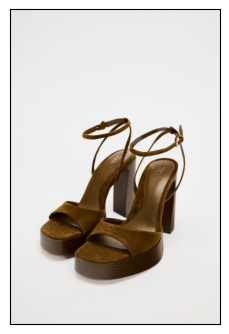

In [11]:
print_nodes(nodes)

Nota: Estos son los zapatos que se han añadido en este notebook

# RAG

In [12]:
from llama_index.core.indices.multi_modal.base import MultiModalVectorStoreIndex
from llama_index.core import PromptTemplate
from llama_index.multi_modal_llms.ollama import OllamaMultiModal
from poc_llamaindex_chromadb.etl import etl_women
from poc_llamaindex_chromadb.ingestion import ingestion
from dotenv import load_dotenv
from llama_index.core.query_engine import CustomQueryEngine
from llama_index.core.retrievers import BaseRetriever
from llama_index.core.response_synthesizers import BaseSynthesizer
from llama_index.core import get_response_synthesizer
from llama_index.llms.ollama import Ollama
from llama_index.core.schema import ImageNode

import gradio as gr

_ = load_dotenv()


class RAGStringQueryEngine(CustomQueryEngine):
    """RAG Query Engine."""

    retriever: BaseRetriever
    response_synthesizer: BaseSynthesizer
    llm:Ollama
    qa_prompt: PromptTemplate

    def custom_query(self, query: str):
        # Busqueda semantica de nodos relevantes
        nodes = self.retriever.retrieve(query)
        #Extraer el contentido de los nodos
        context_str = "\n\n".join([n.node.get_content() for n in nodes])

        #Generar la respuesta
        response = self.llm.complete(
            self.qa_prompt.format(context_str=context_str, query_str=query)
        )
        return str(response), nodes



def multimodal_rag(index: MultiModalVectorStoreIndex, model:str ='llava:13b', k:int=1):
    """
    Create a Rag Engine from a MultiModalIndex and a LLM.
    """

    # define prompt
    qa_prompt = PromptTemplate(
    "Context information is below.\n"
    "---------------------\n"
    "Context: {context_str}\n"
    "---------------------\n"
    "Given the context information and not prior knowledge, "
    "answer the query.\n"
    "Query: {query_str}\n"
    "Answer: "
)

    # define the model
    llm = Ollama(model=model, request_timeout=60.0)

    # define response synthesizer
    synthesizer = get_response_synthesizer(response_mode="compact",llm=llm)


    # degine retriever
    retriever = index.as_retriever(similarity_top_k=k, image_similarity_top_k=k)

    # instantiate the query engine
    rag_engine = RAGStringQueryEngine(
    retriever=retriever,
    response_synthesizer=synthesizer,
    llm=llm,
    qa_prompt=qa_prompt,
    )

    return rag_engine



In [13]:
rag_engine =multimodal_rag(index)

* Test

In [14]:
query_str = "Front laces heels"
response , nodes = rag_engine.custom_query(query_str)
response

' It seems like there is a misunderstanding with your question. The context provided is about block heel shoes with buckled strap details and a squared toe design. If you are asking for front lace heels, they would typically be low-top sneakers or dress shoes with laces in the front. However, without more specific information on what exactly "front laces heels" refer to, it is difficult to provide an accurate answer. If you can clarify your query, I would be happy to assist you further.'

In [15]:
nodes

[NodeWithScore(node=TextNode(id_='c635cb6b-52a9-456d-abe4-2d2ef3229b93', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_name': '0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_type': 'text/plain', 'file_size': 271, 'creation_date': '2024-12-06', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1c501927-faa4-42a0-934a-973f3a0942e6', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_name': '0b0df0ed-6a49-4872-a50c-ef528df8d558.tx

**Node ID:** c635cb6b-52a9-456d-abe4-2d2ef3229b93<br>**Similarity:** 0.7287041882952496<br>**Text:** BUCKLED BLOCK HEEL SHOES.Block heel shoes with faux patent leather. Buckled strap details. Buckle...<br>

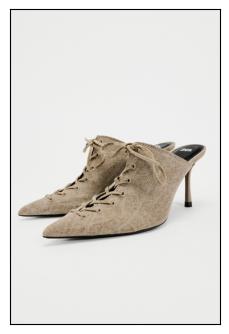

In [16]:
print_nodes(nodes)

* Test

In [47]:
query_str = "Squared toe"
response , nodes = rag_engine.custom_query(query_str)
response

' The squared toe refers to the shape of the toe area in a pair of shoes. In this particular context, the block heel shoes have a squared toe design. This type of toe shape is characterized by straight lines and sharp corners at the tips of the toes, giving the footwear a distinctive and modern look. The squared toe style is often seen in fashion-forward footwear and can be found in various shoe types, including sandals, pumps, and boots.'

In [50]:
nodes

[NodeWithScore(node=TextNode(id_='c635cb6b-52a9-456d-abe4-2d2ef3229b93', embedding=None, metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_name': '0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_type': 'text/plain', 'file_size': 271, 'creation_date': '2024-12-06', 'last_modified_date': '2024-12-06'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1c501927-faa4-42a0-934a-973f3a0942e6', node_type='4', metadata={'file_path': 'd:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\notebooks\\..\\data\\women_txt_img\\0b0df0ed-6a49-4872-a50c-ef528df8d558.txt', 'file_name': '0b0df0ed-6a49-4872-a50c-ef528df8d558.tx

**Node ID:** c635cb6b-52a9-456d-abe4-2d2ef3229b93<br>**Similarity:** 0.6668197485733746<br>**Text:** BUCKLED BLOCK HEEL SHOES.Block heel shoes with faux patent leather. Buckled strap details. Buckle...<br>

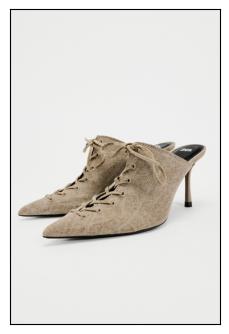

In [51]:
print_nodes(nodes)

* Test

In [40]:
query_str = "ankle strap sandals"
response , nodes = rag_engine.custom_query(query_str)
response

' Based on the given context information, "ankle strap sandals" refers to a type of women\'s footwear that features a high heel with a platform sole, made of suede material, and secured with a buckled ankle strap closure. The heel height is 4.7 inches (12 cm), and the price is $69.9.'

**Node ID:** e9fb0499-94e4-4d6a-905c-971c353ba549<br>**Similarity:** 0.7067437649082745<br>**Text:** CHUNKY HEELED PLATFORM SUEDE SANDALS.Suede sandals. High heels with platform. Buckled ankle strap...<br>

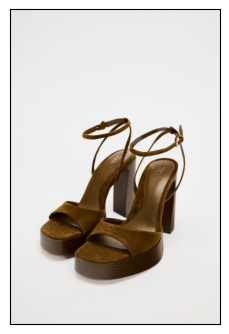

In [41]:
print_nodes(nodes)

* app

In [42]:

def rag_respond(query):
    global index
    global rag_engine
    response , nodes = rag_engine.custom_query(query)
   
    for n in nodes:
        if isinstance(n.node, ImageNode):
            img = n.node.metadata["file_path"]
        else:
            text = n.node.get_content()
    return   gr.Textbox(response), gr.Image(img), gr.Textbox(text)


In [43]:
demo = gr.Interface(
    fn=rag_respond, 
    title="Multimodal Chatbot",
    inputs=[gr.Textbox()],   
    outputs=[gr.Textbox(), gr.Image(), gr.Textbox()])


In [27]:
demo.launch(allowed_paths=['d:\\project_tfg\\pocs\\poc_llamaindex_chromadb\\data\\women_txt_img'])

* Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.
